# Partie Pratique — PFE AgriTech

## Chapitre 3 : Ingénierie des Données
### 3.1 — Collecte et description du dataset

In [ ]:
# Importation des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Bibliothèques importées avec succès")

✅ Bibliothèques importées avec succès


In [ ]:
# Chargement du dataset
df = pd.read_csv('Crop_recommendation.csv')

print("Dimensions du dataset :", df.shape)
print("Nombre de lignes :", df.shape[0])
print("Nombre de colonnes :", df.shape[1])

Dimensions du dataset : (2200, 8)
Nombre de lignes : 2200
Nombre de colonnes : 8


In [ ]:
# Aperçu des premières lignes
print("=== 5 premières lignes du dataset ===")
df.head()

=== 5 premières lignes du dataset ===


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [ ]:
# Types de données de chaque colonne
print("=== Types des colonnes ===")
print(df.dtypes)

=== Types des colonnes ===
N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object


In [ ]:
# Statistiques descriptives
print("=== Statistiques descriptives ===")
df.describe().round(2)

=== Statistiques descriptives ===


,N,P,K,temperature,humidity,ph,rainfall
count,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00
mean,50.55,53.36,48.15,25.62,71.48,6.47,103.46
std,36.92,32.99,50.65,5.06,22.26,0.77,54.96
min,0.00,5.00,5.00,8.83,14.26,3.50,20.21
25%,21.00,28.00,20.00,22.77,60.26,5.97,64.55
50%,37.00,51.00,32.00,25.60,80.47,6.43,94.87
75%,84.25,68.00,49.00,28.56,89.95,6.92,124.27
max,140.00,145.00,205.00,43.68,99.98,9.94,298.56


In [ ]:
# Distribution des cultures (variable cible)
print("=== Nombre d'observations par culture ===")
print(df['label'].value_counts())
print("\nNombre total de cultures distinctes :", df['label'].nunique())

=== Nombre d'observations par culture ===
label
rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100
Name: count, dtype: int64

Nombre total de cultures distinctes : 22


In [ ]:
# Adaptation au contexte marocain
# Cultures présentes dans le dataset ET cultivées au Maroc

cultures_maroc = {
    'maize'       : 'Maïs',
    'rice'        : 'Riz (Gharb, Loukkos)',
    'wheat'       : 'Blé',
    'cotton'      : 'Coton',
    'jute'        : 'Jute (fibres)',
    'chickpea'    : 'Pois chiche',
    'lentil'      : 'Lentille',
    'mungbean'    : 'Haricot mungo',
    'blackgram'   : 'Haricot noir',
    'kidneybeans' : 'Haricot rouge',
    'pigeonpeas'  : 'Pois Angole',
    'mango'       : 'Mangue (Souss)',
    'grapes'      : 'Raisin (Meknès, Benslimane)',
    'watermelon'  : 'Pastèque (Doukkala)',
    'muskmelon'   : 'Melon (Souss-Massa)',
    'orange'      : 'Orange (Souss-Massa)',
    'papaya'      : 'Papaye',
    'pomegranate' : 'Grenade (Tafilalet)',
    'banana'      : 'Banane (Souss)',
    'apple'       : 'Pomme (Moyen Atlas)',
    'coconut'     : 'Cocotier (côte atlantique)',
    'coffee'      : 'Café (rare, zones humides)',
}

print(f"Nombre de cultures communes Inde/Maroc : {len(cultures_maroc)}/22")
print("\nCultures et leurs régions marocaines :")
for en, fr in cultures_maroc.items():
    print(f"  {en:15} → {fr}")

Nombre de cultures communes Inde/Maroc : 22/22

Cultures et leurs régions marocaines :
  maize           → Maïs
  rice            → Riz (Gharb, Loukkos)
  wheat           → Blé
  cotton          → Coton
  jute            → Jute (fibres)
  chickpea        → Pois chiche
  lentil          → Lentille
  mungbean        → Haricot mungo
  blackgram       → Haricot noir
  kidneybeans     → Haricot rouge
  pigeonpeas      → Pois Angole
  mango           → Mangue (Souss)
  grapes          → Raisin (Meknès, Benslimane)
  watermelon      → Pastèque (Doukkala)
  muskmelon       → Melon (Souss-Massa)
  orange          → Orange (Souss-Massa)
  papaya          → Papaye
  pomegranate     → Grenade (Tafilalet)
  banana          → Banane (Souss)
  apple           → Pomme (Moyen Atlas)
  coconut         → Cocotier (côte atlantique)
  coffee          → Café (rare, zones humides)


In [ ]:
# Cultures prioritaires au Maroc (Plan Maroc Vert)
cultures_prioritaires = [
    'maize', 'cotton', 'chickpea', 'lentil',
    'kidneybeans', 'mango', 'grapes', 'watermelon',
    'muskmelon', 'orange', 'pomegranate', 'banana',
    'apple', 'rice'
]

df_maroc = df[df['label'].isin(cultures_prioritaires)].copy()
df_maroc['label_fr'] = df_maroc['label'].map(cultures_maroc)

print(f"Dataset adapté au Maroc : {df_maroc.shape[0]} observations")
print(f"Nombre de cultures retenues : {df_maroc['label'].nunique()}")
print(df_maroc['label_fr'].value_counts())

Dataset adapté au Maroc : 1400 observations
Nombre de cultures retenues : 14
label_fr
Riz (Gharb, Loukkos)           100
Maïs                           100
Pois chiche                    100
Haricot rouge                  100
Lentille                       100
Grenade (Tafilalet)            100
Banane (Souss)                 100
Mangue (Souss)                 100
Raisin (Meknès, Benslimane)    100
Pastèque (Doukkala)            100
Melon (Souss-Massa)            100
Pomme (Moyen Atlas)            100
Orange (Souss-Massa)           100
Coton                          100
Name: count, dtype: int64


In [ ]:
# Définition des profils climatiques des régions marocaines
regions_maroc = {
    'Souss-Massa'   : {'temp_min': 18, 'temp_max': 32, 'rain_min': 150, 'rain_max': 300, 'cultures': ['orange', 'banana', 'muskmelon', 'watermelon', 'mango']},
    'Gharb-Loukkos' : {'temp_min': 15, 'temp_max': 30, 'rain_min': 400, 'rain_max': 800, 'cultures': ['rice', 'maize', 'cotton']},
    'Meknès-Fès'    : {'temp_min': 10, 'temp_max': 35, 'rain_min': 350, 'rain_max': 600, 'cultures': ['grapes', 'apple', 'lentil', 'chickpea']},
    'Tafilalet'     : {'temp_min': 15, 'temp_max': 42, 'rain_min': 50,  'rain_max': 150, 'cultures': ['pomegranate', 'mango']},
    'Doukkala'      : {'temp_min': 16, 'temp_max': 30, 'rain_min': 300, 'rain_max': 500, 'cultures': ['maize', 'watermelon', 'cotton']},
}

print("=== Profils climatiques des régions marocaines ===")
for region, params in regions_maroc.items():
    print(f"\n{region}")
    print(f"  Température : {params['temp_min']}°C – {params['temp_max']}°C")
    print(f"  Pluviométrie : {params['rain_min']} – {params['rain_max']} mm")
    print(f"  Cultures adaptées : {', '.join(params['cultures'])}")

=== Profils climatiques des régions marocaines ===

Souss-Massa
  Température : 18°C – 32°C
  Pluviométrie : 150 – 300 mm
  Cultures adaptées : orange, banana, muskmelon, watermelon, mango

Gharb-Loukkos
  Température : 15°C – 30°C
  Pluviométrie : 400 – 800 mm
  Cultures adaptées : rice, maize, cotton

Meknès-Fès
  Température : 10°C – 35°C
  Pluviométrie : 350 – 600 mm
  Cultures adaptées : grapes, apple, lentil, chickpea

Tafilalet
  Température : 15°C – 42°C
  Pluviométrie : 50 – 150 mm
  Cultures adaptées : pomegranate, mango

Doukkala
  Température : 16°C – 30°C
  Pluviométrie : 300 – 500 mm
  Cultures adaptées : maize, watermelon, cotton


### 3.1.1 — Vérification de la qualité des données


In [ ]:
# Vérification des valeurs manquantes
print("=== Valeurs manquantes par colonne ===")
print(df.isnull().sum())
print("\nTotal valeurs manquantes :", df.isnull().sum().sum())

print("\n=== Doublons ===")
print("Nombre de doublons :", df.duplicated().sum())

=== Valeurs manquantes par colonne ===
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Total valeurs manquantes : 0

=== Doublons ===
Nombre de doublons : 0


In [ ]:
# Détection des outliers par méthode IQR
print("=== Détection des outliers ===\n")

colonnes = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

for col in colonnes:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col:15} : {len(outliers):3} outliers détectés")

=== Détection des outliers ===

N               :   0 outliers détectés
P               : 138 outliers détectés
K               : 200 outliers détectés
temperature     :  86 outliers détectés
humidity        :  30 outliers détectés
ph              :  57 outliers détectés
rainfall        : 100 outliers détectés


In [ ]:
# Tableau récapitulatif de la qualité
print("=" * 45)
print("   BILAN QUALITE DU DATASET")
print("=" * 45)
print(f"  Nombre de lignes        : {df.shape[0]}")
print(f"  Nombre de colonnes      : {df.shape[1]}")
print(f"  Valeurs manquantes      : {df.isnull().sum().sum()}")
print(f"  Doublons                : {df.duplicated().sum()}")
print(f"  Cultures distinctes     : {df['label'].nunique()}")
print(f"  Observations/culture    : {df.shape[0] // df['label'].nunique()}")
print("=" * 45)
print("  CONCLUSION : Dataset propre, pret a l'emploi")
print("=" * 45)

   BILAN QUALITE DU DATASET
  Nombre de lignes        : 2200
  Nombre de colonnes      : 8
  Valeurs manquantes      : 0
  Doublons                : 0
  Cultures distinctes     : 22
  Observations/culture    : 100
  CONCLUSION : Dataset propre, pret a l'emploi


### 3.2 — Analyse Exploratoire des Données (EDA)

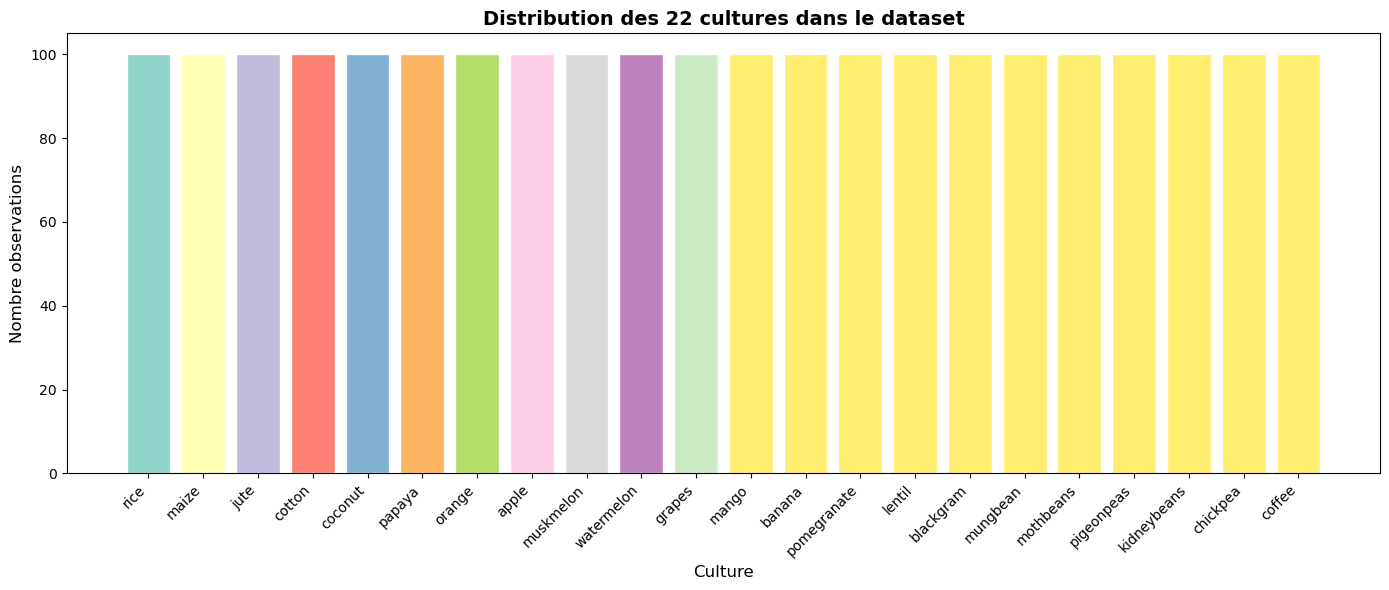

In [ ]:
# Graphique 1 : Distribution des cultures
plt.figure(figsize=(14, 6))
cultures_count = df['label'].value_counts()
colors = plt.cm.Set3(range(len(cultures_count)))
plt.bar(cultures_count.index, cultures_count.values, color=colors, edgecolor='white')
plt.title('Distribution des 22 cultures dans le dataset', fontsize=14, fontweight='bold')
plt.xlabel('Culture', fontsize=12)
plt.ylabel('Nombre observations', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('graphique1_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


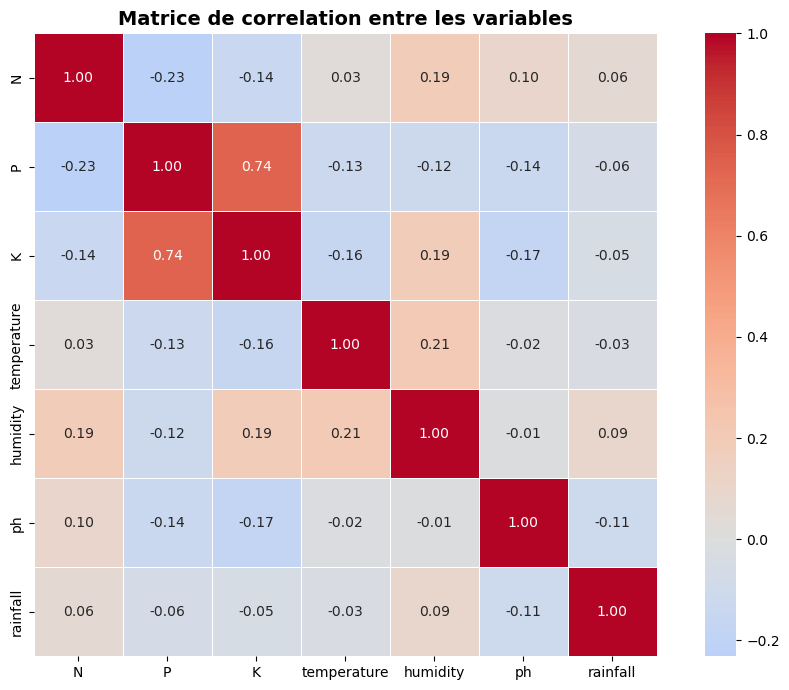

In [ ]:
# Graphique 2 : Heatmap des corrélations
plt.figure(figsize=(10, 7))
correlation = df[['N','P','K','temperature','humidity','ph','rainfall']].corr()
sns.heatmap(correlation, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5)
plt.title('Matrice de correlation entre les variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('graphique2_correlation.png', dpi=150, bbox_inches='tight')
plt.show()


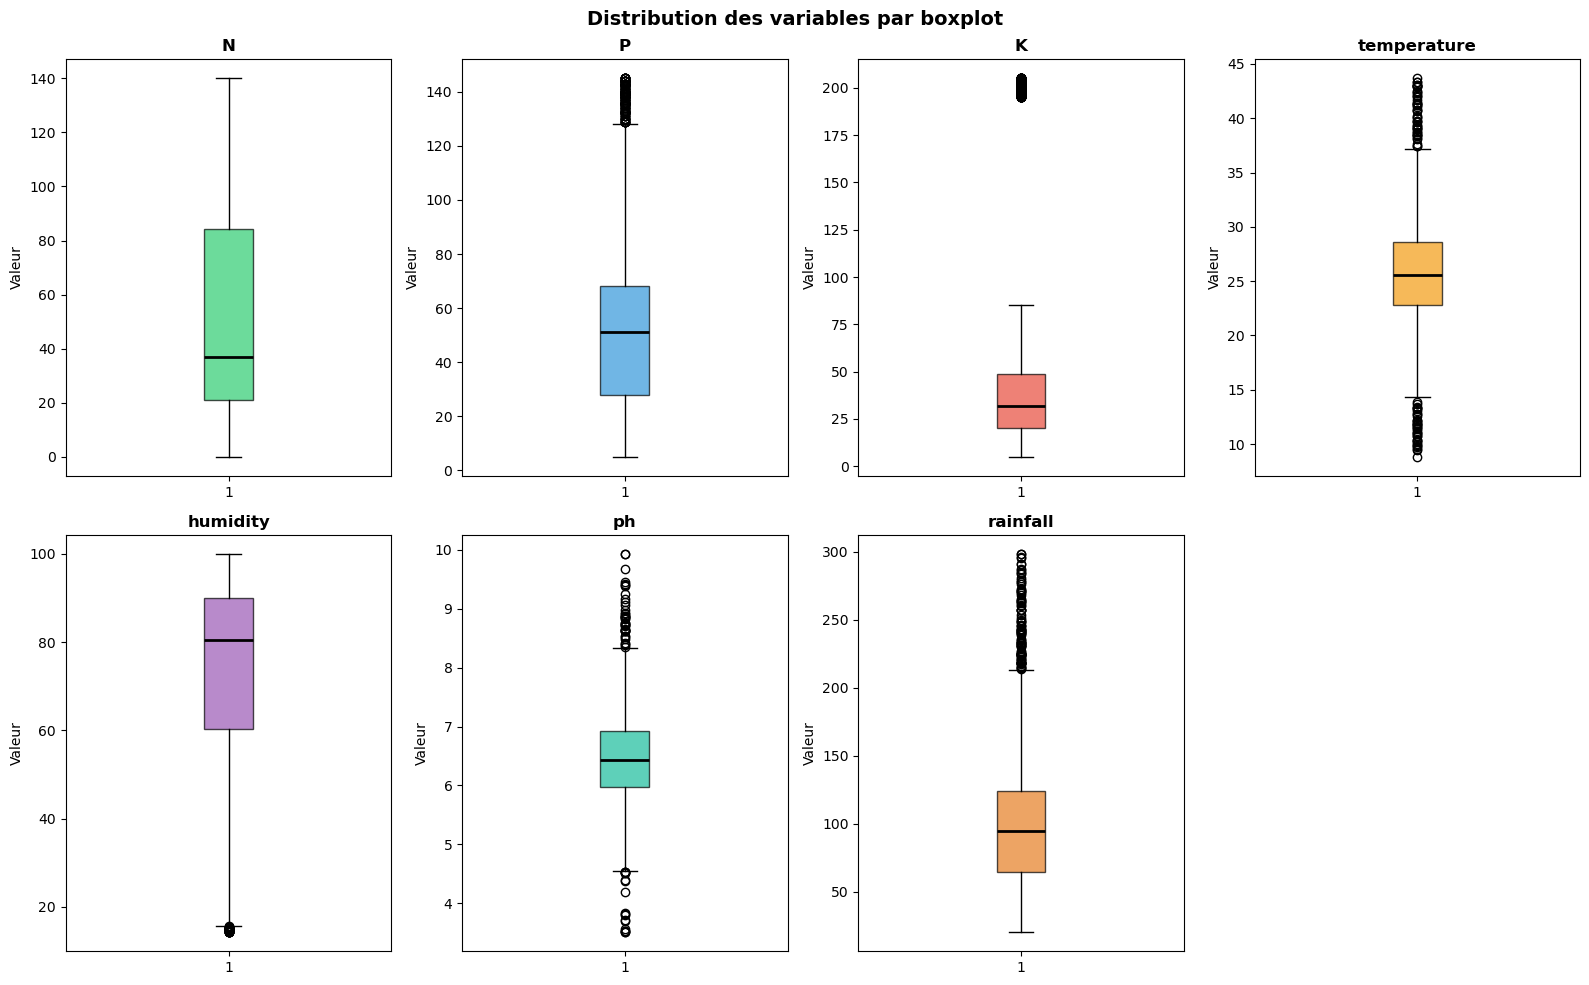

In [ ]:
# Graphique 3 : Boxplots des 7 variables
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

colonnes = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
couleurs = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22']

for i, (col, couleur) in enumerate(zip(colonnes, couleurs)):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor=couleur, alpha=0.7),
                    medianprops=dict(color='black', linewidth=2))
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Valeur')

axes[7].axis('off')
plt.suptitle('Distribution des variables par boxplot', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('graphique3_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

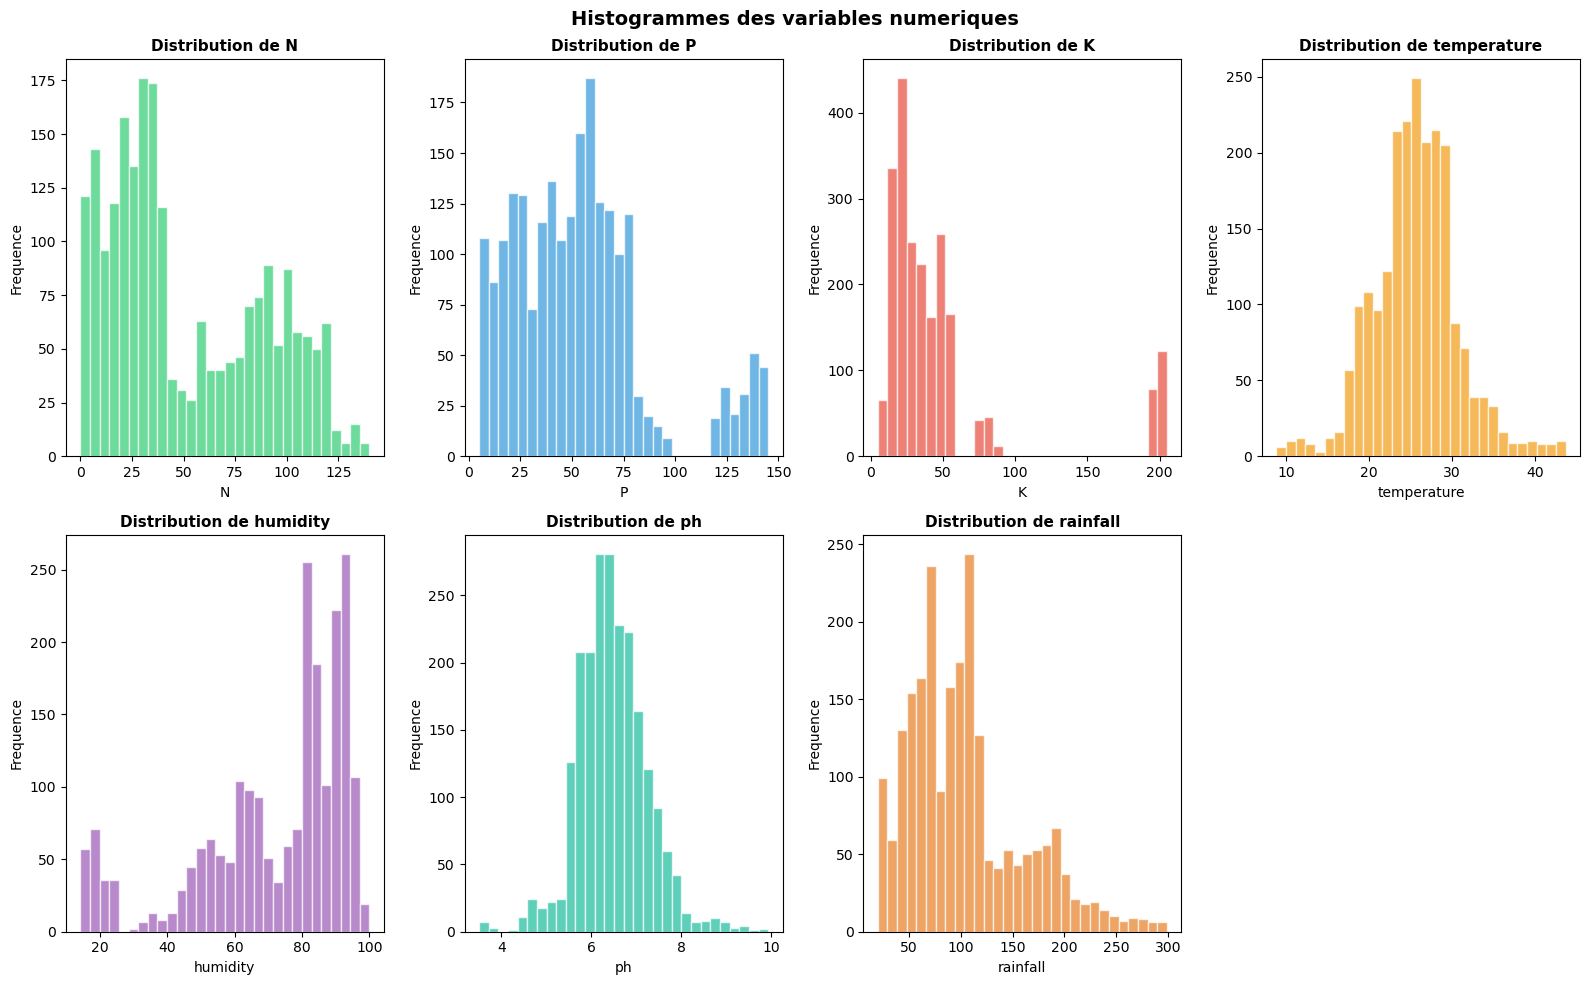

In [ ]:
# Graphique 4 : Histogrammes de distribution
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

colonnes = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
couleurs = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22']

for i, (col, couleur) in enumerate(zip(colonnes, couleurs)):
    axes[i].hist(df[col], bins=30, color=couleur, alpha=0.7, edgecolor='white')
    axes[i].set_title(f'Distribution de {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequence')

axes[7].axis('off')
plt.suptitle('Histogrammes des variables numeriques', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('graphique4_histogrammes.png', dpi=150, bbox_inches='tight')
plt.show()

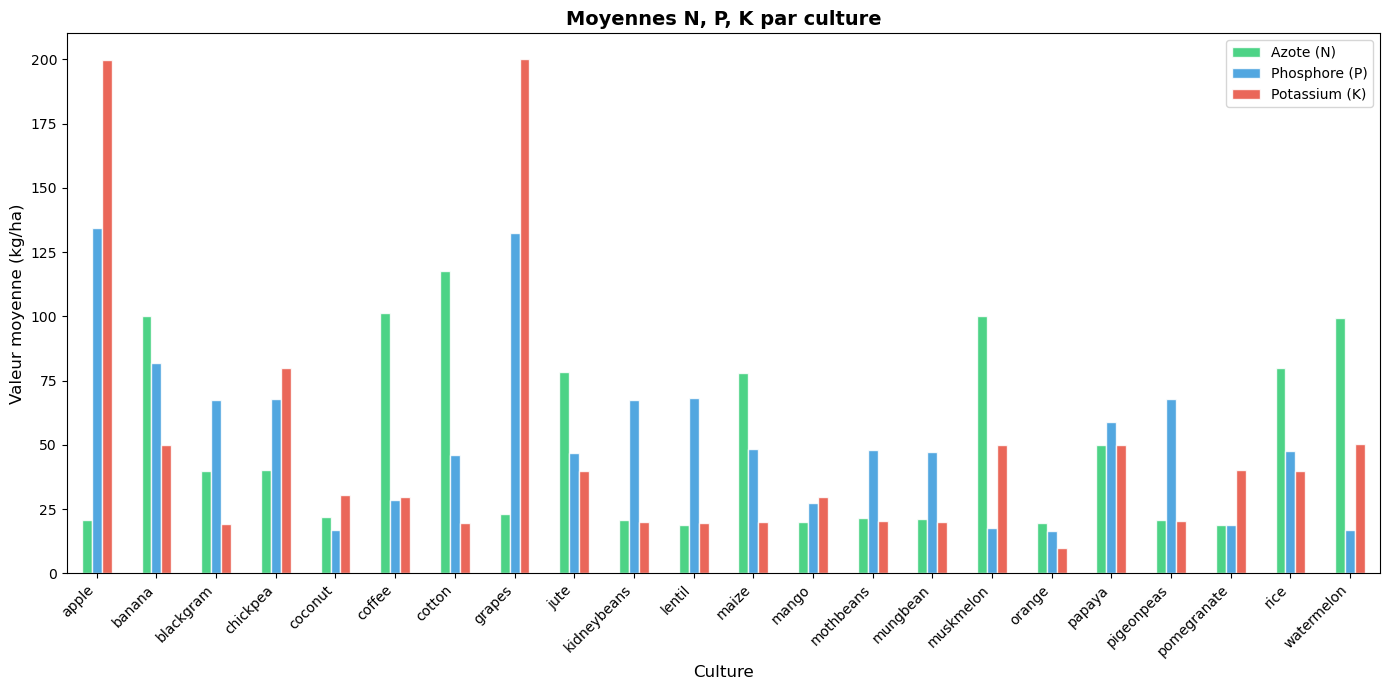

In [ ]:
# Graphique 5 : Moyennes N, P, K par culture (adapte Maroc)
df_grouped = df.groupby('label')[['N','P','K']].mean().round(1)

df_grouped.plot(kind='bar', figsize=(14, 7), 
                color=['#2ecc71', '#3498db', '#e74c3c'],
                edgecolor='white', alpha=0.85)
plt.title('Moyennes N, P, K par culture', fontsize=14, fontweight='bold')
plt.xlabel('Culture', fontsize=12)
plt.ylabel('Valeur moyenne (kg/ha)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(['Azote (N)', 'Phosphore (P)', 'Potassium (K)'])
plt.tight_layout()
plt.savefig('graphique5_npk.png', dpi=150, bbox_inches='tight')
plt.show()

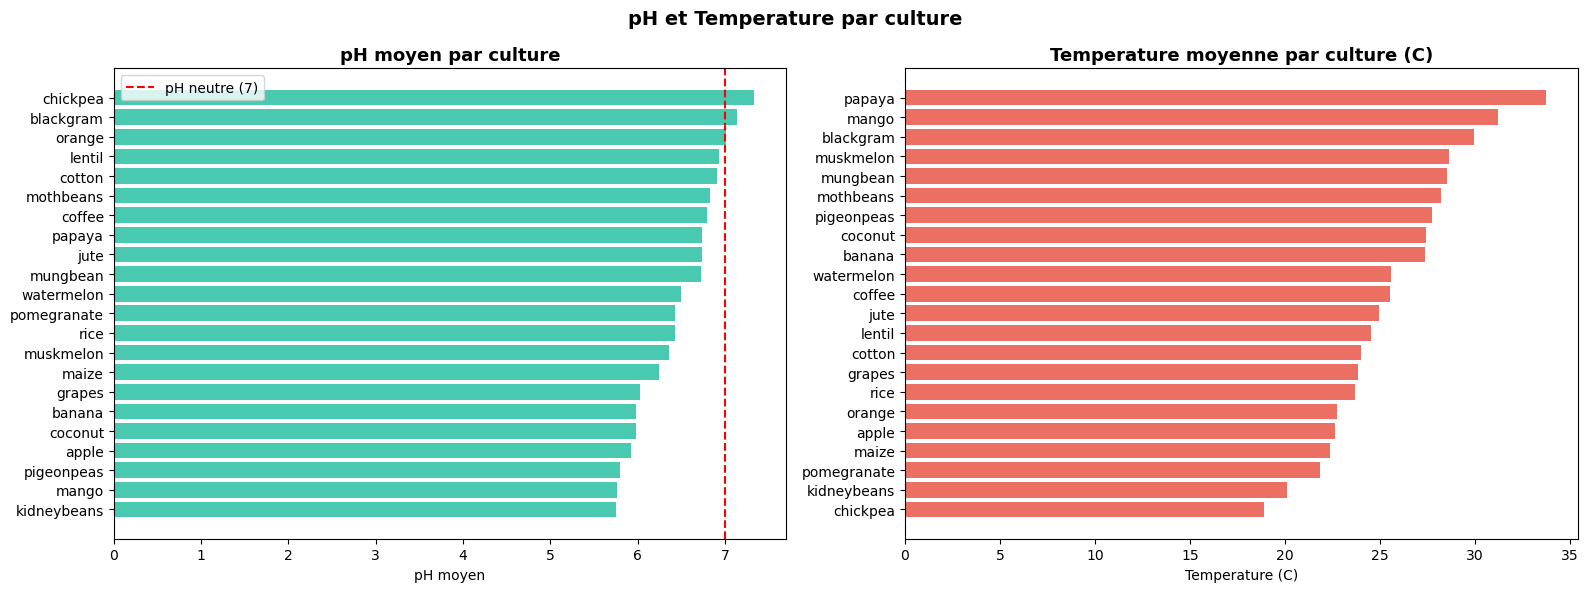

In [ ]:
# Graphique 6 : pH moyen par culture
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# pH par culture
ph_means = df.groupby('label')['ph'].mean().sort_values()
ax1.barh(ph_means.index, ph_means.values, color='#1abc9c', alpha=0.8)
ax1.set_title('pH moyen par culture', fontsize=13, fontweight='bold')
ax1.set_xlabel('pH moyen')
ax1.axvline(x=7, color='red', linestyle='--', label='pH neutre (7)')
ax1.legend()

# Temperature par culture
temp_means = df.groupby('label')['temperature'].mean().sort_values()
ax2.barh(temp_means.index, temp_means.values, color='#e74c3c', alpha=0.8)
ax2.set_title('Temperature moyenne par culture (C)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Temperature (C)')

plt.suptitle('pH et Temperature par culture', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('graphique6_ph_temperature.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 — Prétraitement des données (Data Preprocessing)


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Encodage de la variable cible
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])

print("=== Encodage de la variable cible ===")
print("\nCorrespondance culture -> chiffre :")
for culture, code in zip(le.classes_, range(len(le.classes_))):
    print(f"  {culture:15} -> {code}")

=== Encodage de la variable cible ===

Correspondance culture -> chiffre :
  apple           -> 0
  banana          -> 1
  blackgram       -> 2
  chickpea        -> 3
  coconut         -> 4
  coffee          -> 5
  cotton          -> 6
  grapes          -> 7
  jute            -> 8
  kidneybeans     -> 9
  lentil          -> 10
  maize           -> 11
  mango           -> 12
  mothbeans       -> 13
  mungbean        -> 14
  muskmelon       -> 15
  orange          -> 16
  papaya          -> 17
  pigeonpeas      -> 18
  pomegranate     -> 19
  rice            -> 20
  watermelon      -> 21


In [ ]:
# Séparation des variables explicatives et la variable cible
X = df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']]
y = df['label_encoded']

print("=== Séparation X et y ===")
print(f"Variables explicatives (X) : {X.shape}")
print(f"Variable cible (y)         : {y.shape}")
print(f"\nColonnes de X : {list(X.columns)}")
print(f"Valeurs uniques de y : {y.nunique()} classes")

=== Séparation X et y ===
Variables explicatives (X) : (2200, 7)
Variable cible (y)         : (2200,)

Colonnes de X : ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
Valeurs uniques de y : 22 classes


In [ ]:
from sklearn.preprocessing import StandardScaler

# Normalisation des données
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("=== Normalisation StandardScaler ===")
print("\nAvant normalisation (moyennes) :")
print(X.mean().round(2))
print("\nApres normalisation (moyennes) :")
print(X_scaled.mean(axis=0).round(4))
print("\nApres normalisation (ecarts-types) :")
print(X_scaled.std(axis=0).round(4))

=== Normalisation StandardScaler ===

Avant normalisation (moyennes) :
N               50.55
P               53.36
K               48.15
temperature     25.62
humidity        71.48
ph               6.47
rainfall       103.46
dtype: float64

Apres normalisation (moyennes) :
[-0.  0. -0.  0. -0. -0.  0.]

Apres normalisation (ecarts-types) :
[1. 1. 1. 1. 1. 1. 1.]


In [ ]:
from sklearn.model_selection import train_test_split

# Division train/test 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("=== Division Train / Test ===")
print(f"\nTaille totale      : {X_scaled.shape[0]} observations")
print(f"Taille Train (80%) : {X_train.shape[0]} observations")
print(f"Taille Test  (20%) : {X_test.shape[0]} observations")
print(f"\nNombre de features : {X_train.shape[1]}")
print(f"\nDistribution y_train :")
import pandas as pd
print(pd.Series(y_train).value_counts().sort_index())

=== Division Train / Test ===

Taille totale      : 2200 observations
Taille Train (80%) : 1760 observations
Taille Test  (20%) : 440 observations

Nombre de features : 7

Distribution y_train :
label_encoded
0     80
1     80
2     80
3     80
4     80
5     80
6     80
7     80
8     80
9     80
10    80
11    80
12    80
13    80
14    80
15    80
16    80
17    80
18    80
19    80
20    80
21    80
Name: count, dtype: int64


In [ ]:
import pickle

# Sauvegarde pour utilisation dans l'application web
pickle.dump(le, open('label_encoder.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))

print("=== Sauvegarde ===")
print("label_encoder.pkl sauvegarde !")
print("scaler.pkl sauvegarde !")
print("\nFichiers disponibles pour l'application web :")

=== Sauvegarde ===
label_encoder.pkl sauvegarde !
scaler.pkl sauvegarde !

Fichiers disponibles pour l'application web :


## Chapitre 4 — Modélisation Prédictive (Machine Learning)
### 4.1 — Entraînement et comparaison des algorithmes

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import time

print("✅ Algorithmes importés avec succès")

✅ Algorithmes importés avec succès


In [ ]:
modeles = {
    'Decision Tree' : DecisionTreeClassifier(random_state=42),
    'Random Forest' : RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN'           : KNeighborsClassifier(n_neighbors=5)
}

resultats = {}

print("=== Entraînement des modèles ===\n")
for nom, modele in modeles.items():
    debut = time.time()
    modele.fit(X_train, y_train)
    duree = round(time.time() - debut, 2)
    y_pred = modele.predict(X_test)
    acc = round(accuracy_score(y_test, y_pred) * 100, 2)
    resultats[nom] = {'accuracy': acc, 'duree': duree,
                      'modele': modele, 'y_pred': y_pred}
    print(f"{nom:20} | Accuracy : {acc}%  | Temps : {duree}s")

=== Entraînement des modèles ===

Decision Tree        | Accuracy : 97.95%  | Temps : 0.02s
Random Forest        | Accuracy : 99.55%  | Temps : 0.47s
KNN                  | Accuracy : 97.95%  | Temps : 0.01s


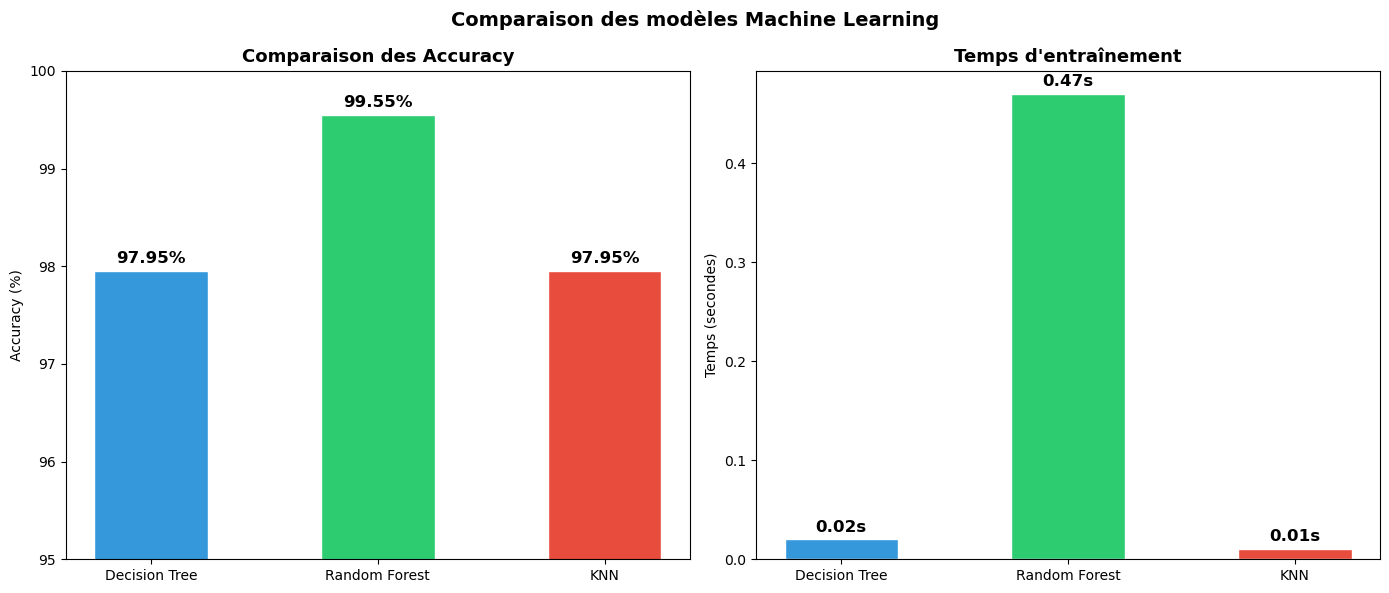

In [ ]:
noms = list(resultats.keys())
accuracies = [resultats[n]['accuracy'] for n in noms]
durees = [resultats[n]['duree'] for n in noms]
couleurs = ['#3498db', '#2ecc71', '#e74c3c']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

bars1 = ax1.bar(noms, accuracies, color=couleurs,
                edgecolor='white', width=0.5)
ax1.set_title('Comparaison des Accuracy',
              fontsize=13, fontweight='bold')
ax1.set_ylabel('Accuracy (%)')
ax1.set_ylim(95, 100)
for bar, acc in zip(bars1, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.05,
             f'{acc}%', ha='center', va='bottom',
             fontweight='bold', fontsize=12)

bars2 = ax2.bar(noms, durees, color=couleurs,
                edgecolor='white', width=0.5)
ax2.set_title("Temps d'entraînement",
              fontsize=13, fontweight='bold')
ax2.set_ylabel('Temps (secondes)')
for bar, d in zip(bars2, durees):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{d}s', ha='center', va='bottom',
             fontweight='bold', fontsize=12)

plt.suptitle('Comparaison des modèles Machine Learning',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('graphique7_comparaison_modeles.png',
            dpi=150, bbox_inches='tight')
plt.show()


### 4.2 — Évaluation des performances (Matrice de confusion, Accuracy)

In [ ]:
from sklearn.metrics import classification_report

rf = resultats['Random Forest']['modele']
y_pred_rf = resultats['Random Forest']['y_pred']

print("=== Rapport de classification — Random Forest ===\n")
print(classification_report(y_test, y_pred_rf,
                            target_names=le.classes_))

=== Rapport de classification — Random Forest ===

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1

In [ ]:
# Métriques exactes du modèle (valeurs précises sans arrondi)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("=== MÉTRIQUES EXACTES DU MODÈLE RANDOM FOREST ===\n")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_rf)*100:.2f}%")
print(f"Precision : {precision_score(y_test, y_pred_rf, average='weighted')*100:.2f}%")
print(f"Recall    : {recall_score(y_test, y_pred_rf, average='weighted')*100:.2f}%")
print(f"F1-score  : {f1_score(y_test, y_pred_rf, average='weighted')*100:.2f}%")

# Nombre d'erreurs
nb_erreurs = (y_pred_rf != y_test).sum()
print(f"\nLe modèle commet {nb_erreurs} erreurs sur {len(y_test)} observations de test")

=== MÉTRIQUES EXACTES DU MODÈLE RANDOM FOREST ===

Accuracy  : 99.55%
Precision : 99.57%
Recall    : 99.55%
F1-score  : 99.55%

Le modèle commet 2 erreurs sur 440 observations de test


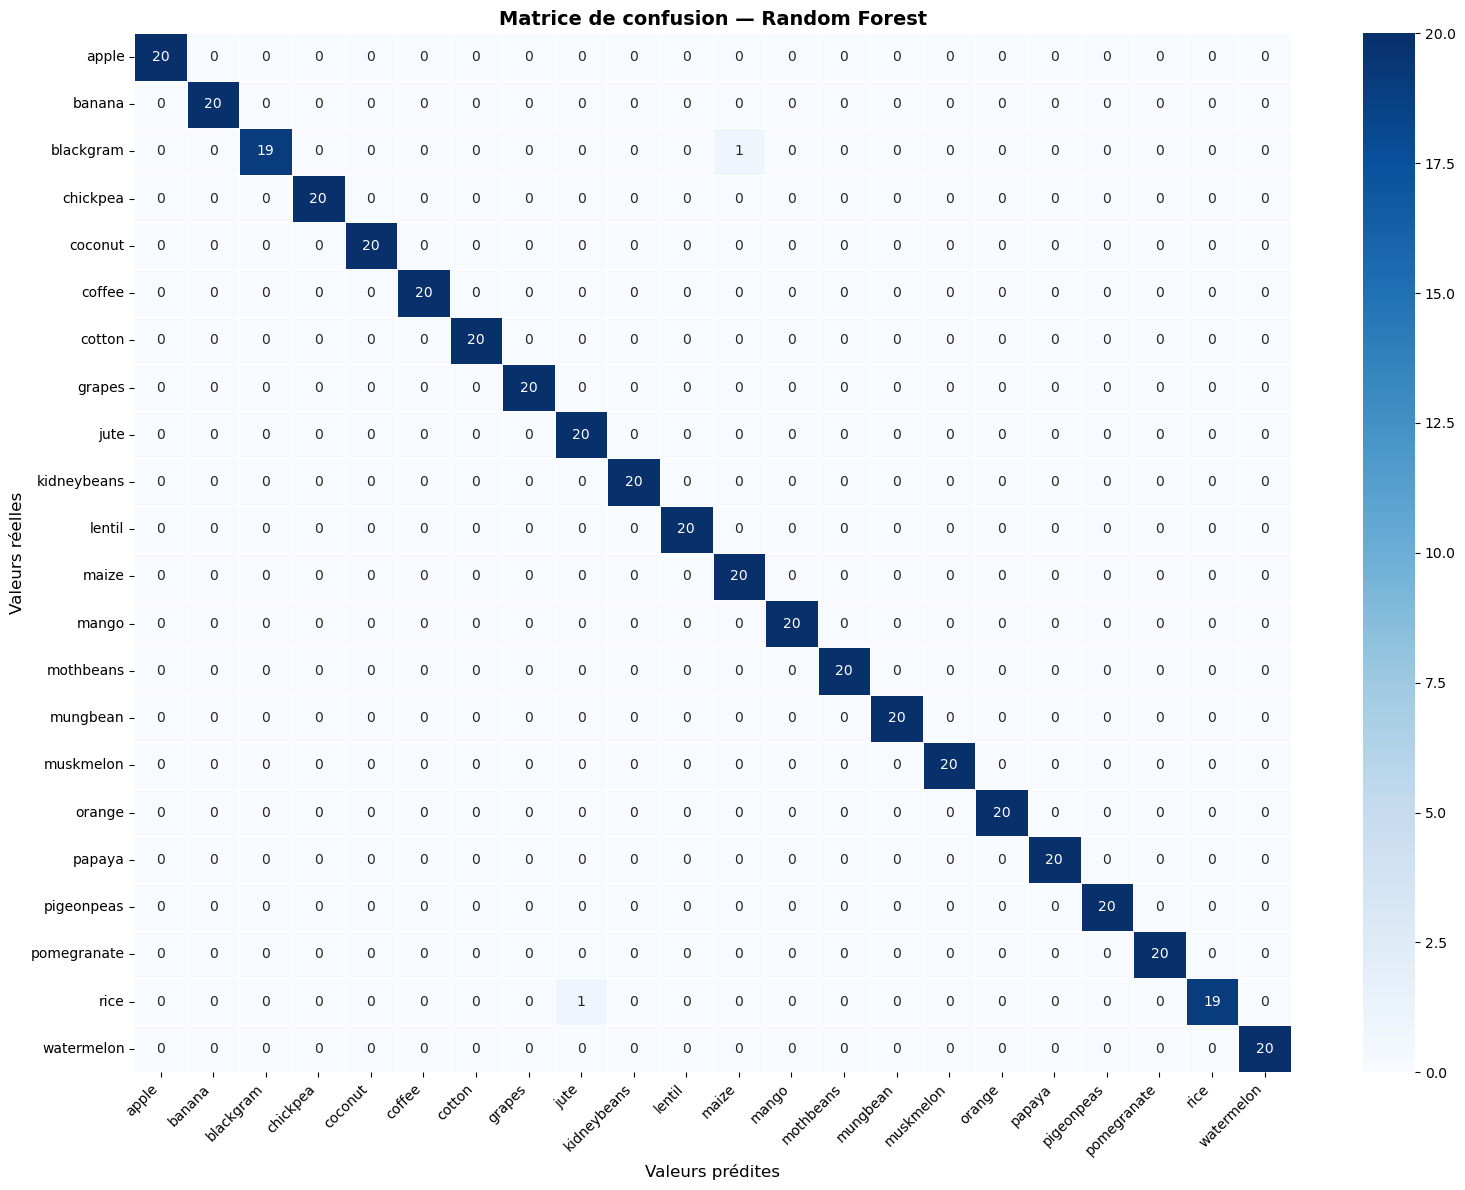

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(16, 12))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            linewidths=0.5)
plt.title('Matrice de confusion — Random Forest',
          fontsize=14, fontweight='bold')
plt.ylabel('Valeurs réelles', fontsize=12)
plt.xlabel('Valeurs prédites', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('graphique8_matrice_confusion.png',
            dpi=150, bbox_inches='tight')
plt.show()

### 4.3 — Sélection du modèle optimal et analyse des variables déterminantes

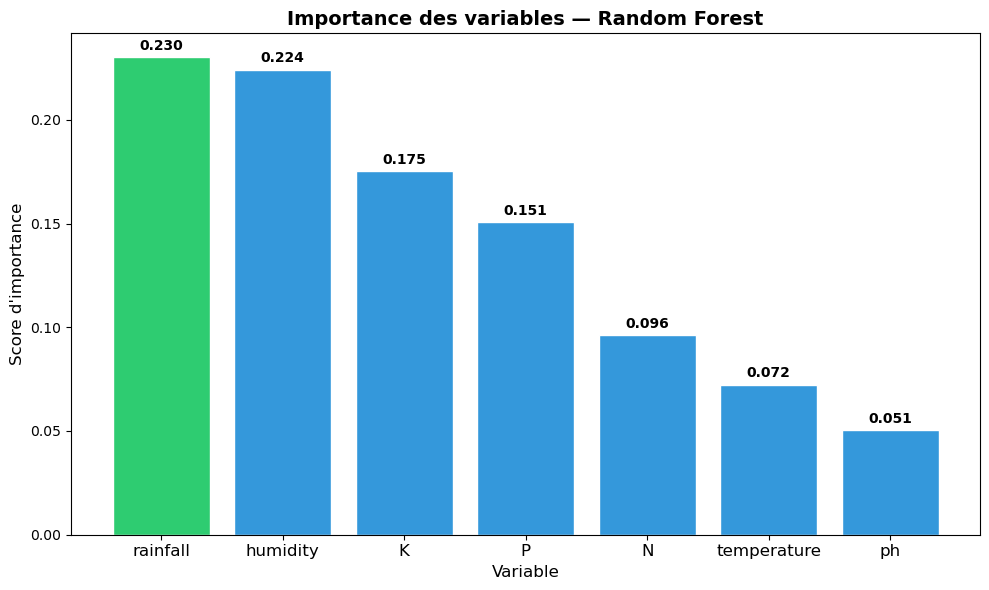

In [ ]:
import numpy as np

importances = rf.feature_importances_
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
couleurs = ['#2ecc71' if i == 0 else '#3498db'
            for i in range(len(features))]
bars = plt.bar(range(len(features)),
               importances[indices],
               color=couleurs, edgecolor='white')

plt.xticks(range(len(features)),
           [features[i] for i in indices],
           fontsize=12)
plt.title('Importance des variables — Random Forest',
          fontsize=14, fontweight='bold')
plt.ylabel("Score d'importance", fontsize=12)
plt.xlabel("Variable", fontsize=12)

for bar, imp in zip(bars, importances[indices]):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.002,
             f'{imp:.3f}', ha='center', va='bottom',
             fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('graphique9_feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================
# VALIDATION CROISÉE (5-FOLD)
# ============================================
# Objectif : confirmer la robustesse du modèle
# et écarter le risque de surapprentissage

from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

# Découpage en 5 plis, en gardant l'équilibre des cultures
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Calcul des 5 scores d'accuracy
scores = cross_val_score(rf, X_scaled, y, cv=cv, scoring='accuracy')

# Affichage des résultats
print("=== VALIDATION CROISÉE 5-FOLD ===\n")
print("Scores des 5 plis :", np.round(scores * 100, 2))
print(f"Accuracy moyenne  : {scores.mean() * 100:.2f} %")
print(f"Écart-type        : {scores.std() * 100:.2f} %")

=== VALIDATION CROISÉE 5-FOLD ===

Scores des 5 plis : [ 99.55  99.32 100.    99.77  99.09]
Accuracy moyenne  : 99.55 %
Écart-type        : 0.32 %


In [ ]:
!pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/48.9 MB 549.8 kB/s eta 0:01:29
   ---------------------------------------- 0.5/48.9 MB 549.8 kB/s eta 0:01:29
   ---------------------------------------- 0.5/48.9 MB 549.8 kB/s eta 0:01:29
    --------------------------------------- 0.8/48.9 MB 521.5 kB/s eta 0:01:33
    --------------------------------------- 1.0/48.9 MB 590.9 kB/s eta 0:01:22
   - -------------------------------------- 1.6/48.9 MB 868.1 kB/s eta 0:00:55
   - -------------------------------------- 1.8/48.9 MB 937.1 kB/s eta 0:00:51
   - -------------------------------------- 2.1/48.9 MB 972.1 kB/s eta 0:00:49
   -- ------------------------------------- 2.9/48.9 MB 1.2 MB/s eta 0:00:38
   --- ----

In [ ]:
# ============================================================
# COMPARAISON AVEC XGBoost (méthode récente de boosting)
# ============================================================
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1) Entraînement de XGBoost sur les mêmes données que les autres modèles
xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train)

# 2) Prédictions
y_pred_xgb = xgb_model.predict(X_test)

# 3) Calcul des métriques
acc  = accuracy_score(y_test, y_pred_xgb) * 100
prec = precision_score(y_test, y_pred_xgb, average='weighted') * 100
rec  = recall_score(y_test, y_pred_xgb, average='weighted') * 100
f1   = f1_score(y_test, y_pred_xgb, average='weighted') * 100

print("=== RÉSULTATS XGBoost ===")
print(f"Accuracy  : {acc:.2f} %")
print(f"Precision : {prec:.2f} %")
print(f"Recall    : {rec:.2f} %")
print(f"F1-score  : {f1:.2f} %")

=== RÉSULTATS XGBoost ===
Accuracy  : 99.09 %
Precision : 99.15 %
Recall    : 99.09 %
F1-score  : 99.08 %


In [ ]:
import pickle
import os

pickle.dump(rf, open('model.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))
pickle.dump(le, open('label_encoder.pkl', 'wb'))

print("=== Sauvegarde des fichiers ===")
print("✅ model.pkl sauvegardé !")
print("✅ scaler.pkl sauvegardé !")
print("✅ label_encoder.pkl sauvegardé !")

pkl_files = [f for f in os.listdir() if f.endswith('.pkl')]
print(f"\nFichiers pkl disponibles : {pkl_files}")
print(f"Dossier actuel : {os.getcwd()}")

=== Sauvegarde des fichiers ===
✅ model.pkl sauvegardé !
✅ scaler.pkl sauvegardé !
✅ label_encoder.pkl sauvegardé !

Fichiers pkl disponibles : ['label_encoder.pkl', 'model.pkl', 'scaler.pkl']
Dossier actuel : C:\Users\hp\Desktop\PFE\MonPFE
